# 1. 방송 이벤트 정리 & 분석 설계

**목적**: 방송 일정, 촬영지, 시청률을 정리하고 분석 가능 구간을 식별한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from config import BROADCAST_DIR, BROADCAST_DONG_MAP, read_csv_auto

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1.1 방송 목록 로드

In [2]:
broadcast = read_csv_auto(BROADCAST_DIR / 'broadcast_data.csv')
locations = read_csv_auto(BROADCAST_DIR / 'broadcast_locations.csv')
budget = read_csv_auto(BROADCAST_DIR / 'broadcast_budget_summary.csv')
effects = read_csv_auto(BROADCAST_DIR / 'broadcast_effects_2025.csv')

print(f"방송 {len(broadcast)}건, 촬영지 {len(locations)}건")
broadcast[['연도', '프로그램명', '방송사', '방영일', '시청률_pct', '촬영지']].fillna('-')

방송 9건, 촬영지 24건


,연도,프로그램명,방송사,방영일,시청률_pct,촬영지
0,2025,전국노래자랑 아산시편,KBS,2025-06-08,6.5,신정호 잔디광장
1,2025,전현무계획2,MBN,2025-11-07,1.5,아산시 일원
2,2025,굿모닝 대한민국,KBS,2025-11-12,0.55,"온양온천역광장,족욕체험장,온양온천전통시장,곡교천은행나무길,이순신관광체험센터,현충사,..."
3,2025,6시 내고향,KBS,2025-11-13,5.5,아산시 주요명소
4,2025,박원숙의 같이삽시다 시즌3,KBS,2025-11-24,3.0,"곡교천은행나무길,신정호정원,영인산,외암민속마을,온양온천시장,도고파라다이스,아산스파포레"
5,2025,뛰어야산다2,MBN,2026-01-12,1.5,"신정호정원,곡교천은행나무길,현충사,온천,캠핑장"
6,2026,황제성의 황제파워,SBS,2026-05-09,-,온양온천역 주무대
7,2026,비긴어게인,JTBC,2026-06~07,-,아산시 주요명소
8,2026,구해줘홈즈,MBC,2026-09~10,-,"아산시 일원(자연,교통,정주여건)"


## 1.2 방송 타임라인 시각화

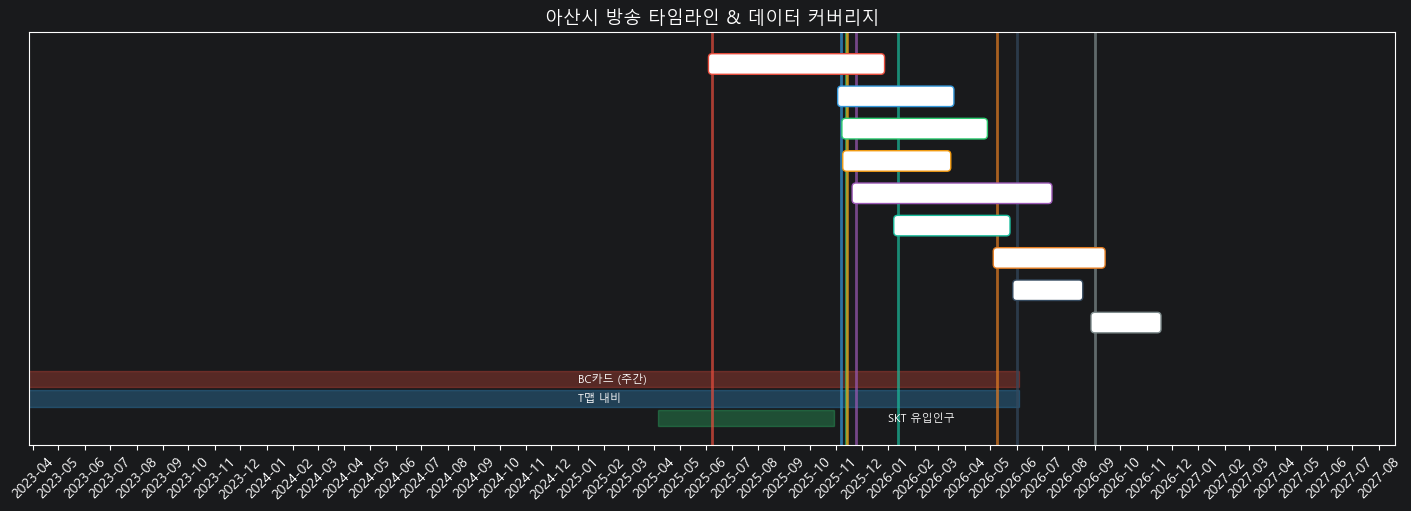

In [8]:
# 방영일 파싱 (확정된 것만)
timeline = broadcast[broadcast['방영일'].notna()].copy()

def parse_air_date(s):
    """방영일 문자열에서 첫 날짜 추출"""
    s = str(s).strip()
    for fmt in ['%Y-%m-%d', '%Y-%m-%d~%d']:
        try:
            return pd.to_datetime(s[:10])
        except:
            continue
    # 2026-06~07 같은 경우
    if len(s) >= 7 and s[4] == '-':
        try:
            return pd.to_datetime(s[:7] + '-01')
        except:
            pass
    return pd.NaT

timeline['air_date'] = timeline['방영일'].apply(parse_air_date)
timeline = timeline.dropna(subset=['air_date']).sort_values('air_date')

# 타임라인 차트
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e', '#7f8c8d']

for i, (_, row) in enumerate(timeline.iterrows()):
    ax.axvline(row['air_date'], color=colors[i % len(colors)], alpha=0.7, linewidth=2)
    rating = f" ({row['시청률_pct']}%)" if pd.notna(row['시청률_pct']) else ""
    ax.text(row['air_date'], len(timeline) - i - 0.5,
            f"{row['프로그램명']}{rating}",
            fontsize=9, ha='left', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors[i % len(colors)]))

# 데이터 커버리지 표시
data_ranges = {
    'BC카드 (주간)': ('2025-01-01', '2026-04-30'),
    'T맵 내비': ('2025-01-01', '2026-04-30'),
    'SKT 유입인구': ('2026-01-01', '2026-02-28'),
}
for j, (name, (s, e)) in enumerate(data_ranges.items()):
    ax.axhspan(-1.5 - j*0.6, -1.0 - j*0.6,
               xmin=(pd.Timestamp(s) - timeline['air_date'].min()).days / (timeline['air_date'].max() - timeline['air_date'].min()).days,
               xmax=(pd.Timestamp(e) - timeline['air_date'].min()).days / (timeline['air_date'].max() - timeline['air_date'].min()).days,
               alpha=0.3, color=colors[j])
    ax.text(pd.Timestamp(s), -1.25 - j*0.6, name, fontsize=8, va='center')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('아산시 방송 타임라인 & 데이터 커버리지', fontsize=13)
ax.set_yticks([])
ax.set_ylim(-1.5 - len(data_ranges)*0.6, len(timeline) + 0.5)
plt.show()

## 1.3 방송별 촬영 읍면동 정리

In [4]:
# 촬영지 → 읍면동 매핑
loc_summary = locations.groupby('프로그램명').agg(
    촬영지수=('촬영지명', 'count'),
    읍면동목록=('읍면동', lambda x: ', '.join(sorted(x.dropna().unique()))),
    관광지유형=('관광지유형', lambda x: ', '.join(sorted(x.dropna().unique()))),
).reset_index()

display(loc_summary)

,프로그램명,촬영지수,읍면동목록,관광지유형
0,6시 내고향,1,복수,명소/먹거리
1,굿모닝 대한민국,7,"신창면, 염치읍, 온천동","교통/도시, 역사/문화, 온천/힐링, 자연/가로수길, 전통시장, 테마파크"
2,뛰어야산다2,5,"염치읍, 온천동","야외레저, 역사/문화, 온천/힐링, 자연/가로수길, 자연/정원"
3,박원숙의 같이삽시다 시즌3,8,"도고면, 송악면, 염치읍, 영인면, 온천동, 음봉면","리조트/레저, 온천/힐링, 자연/가로수길, 자연/산, 자연/정원, 전통/문화, 전통시장"
4,전국노래자랑 아산시편,1,온천동,자연/공원
5,전현무계획2,1,복수,맛집/명소
6,황제성의 황제파워,1,온천동,축제/공연


## 1.4 분석 구간 설계

### 방송 간 간격 문제
- 2025-11월에 4개 방송 집중 → 개별 분리 어려움
- **그룹핑 전략**: 충분히 떨어진 방송만 개별 분석, 나머지는 묶어서 분석

In [5]:
# 방송 간 간격 계산
t = timeline[['프로그램명', 'air_date']].sort_values('air_date').reset_index(drop=True)
t['다음방송까지_일'] = t['air_date'].diff().dt.days
t['이전방송'] = t['프로그램명'].shift(1)
display(t)

print("\n[분석 그룹 제안]")
print("그룹A (단독): 전국노래자랑 (2025-06-08) - 전후 5개월 여유")
print("그룹B (묶음): 11월 캠페인 (전현무계획2 + 굿모닝대한민국 + 6시내고향 + 같이삽시다) - 2025-11~12")
print("그룹C (단독): 뛰어야산다2 (2026-01-12) - SKT 데이터 활용 가능")
print("그룹D (단독): 황제파워 (2026-05-09) - BC카드 데이터 없음 (04월까지)")

,프로그램명,air_date,다음방송까지_일,이전방송
0,전국노래자랑 아산시편,2025-06-08,NaN,NaN
1,전현무계획2,2025-11-07,152.0,전국노래자랑 아산시편
2,굿모닝 대한민국,2025-11-12,5.0,전현무계획2
3,6시 내고향,2025-11-13,1.0,굿모닝 대한민국
4,박원숙의 같이삽시다 시즌3,2025-11-24,11.0,6시 내고향
5,뛰어야산다2,2026-01-12,49.0,박원숙의 같이삽시다 시즌3
6,황제성의 황제파워,2026-05-09,117.0,뛰어야산다2
7,비긴어게인,2026-06-01,23.0,황제성의 황제파워
8,구해줘홈즈,2026-09-01,92.0,비긴어게인



[분석 그룹 제안]
그룹A (단독): 전국노래자랑 (2025-06-08) - 전후 5개월 여유
그룹B (묶음): 11월 캠페인 (전현무계획2 + 굿모닝대한민국 + 6시내고향 + 같이삽시다) - 2025-11~12
그룹C (단독): 뛰어야산다2 (2026-01-12) - SKT 데이터 활용 가능
그룹D (단독): 황제파워 (2026-05-09) - BC카드 데이터 없음 (04월까지)


## 1.5 기존 효과 분석 결과 (참고)

아산시에서 이미 측정한 '같이삽시다' 효과:

In [6]:
if len(effects) > 0:
    display(effects)
else:
    print("기존 효과 데이터 없음")

,프로그램명,효과유형,지표명,수치,단위,기간,비교기준,비고
0,박원숙의 같이삽시다 시즌3,온라인관심도,포털검색량증가,21810,회,방영직후1주간,NaN,외암민속마을+40%/여해나루+1071%등
1,박원숙의 같이삽시다 시즌3,방문객,외지인방문자증가,393921,명,2025년12월,전년동기대비,+13%
2,박원숙의 같이삽시다 시즌3,경제효과,관광소비액증가,4950983,천원,2025년12월,전년동기대비,+3.6%
